In [2]:
import os
import json
import pickle
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
from torch_geometric.nn import GATv2Conv
from shapely.geometry import Point, LineString, Polygon

import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
import torch_geometric
from torch_geometric.data import InMemoryDataset, Data
from shapely import wkt
import contextily as cx
import h3pandas
import seaborn as sns

# Purpose of this notebook is to build the attention graph
 It is the graph that is in the paper: https://arxiv.org/pdf/2502.12352



For each layer ℓ we want:

- the attention matrix A(ℓ) ∈ Rn×n , one for each head h
- Then we can fuse heads inside the layer
- hen we can multiply across layers: matrix multiplication in order to obtain a final attention matrix A ∈ Rn×n
- Then we can use this matrix to create a graph, and then we can use the graph to do whatever we want.

# Data processing
I'm just repeating the steps of Parish3 notebook, check it out for more details.

In [3]:
#load paris geoJson edge and nodes
paris_edges = gpd.read_file('paris_edges.geojson')
paris_nodes = gpd.read_file('paris_nodes.geojson')

#save nodes and edges to geojson
h3_edges = gpd.read_file('h3_edges.geojson')
h3_nodes = gpd.read_file('h3_nodes.geojson')
h3_nodes.index = h3_nodes['h3_09'] 
h3_nodes.drop(columns=['h3_09'], inplace=True)

Text(0.5, 1.0, 'Edges and Nodes')

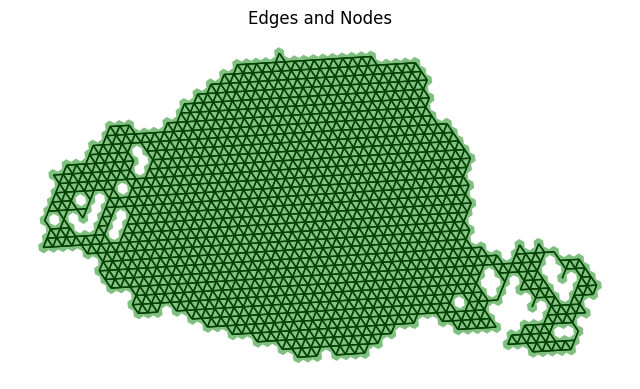

In [4]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))
h3_edges.plot(ax=ax, color='black', linewidth=1, zorder =1)
h3_nodes.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)
ax.set_axis_off()
plt.title('Edges and Nodes')

Basic feature dataset

In [5]:
device = 'cpu'
print(device)
basicHexes = h3_nodes.copy()
basicHexes = basicHexes[['Green View', 'geometry', 'x', 'y']]
y = basicHexes['Green View'].values
X = basicHexes[['x', 'y']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}
edge_index = []
for _, row in h3_edges.iterrows():
    source_idx = node_mapping[row['source']]
    target_idx = node_mapping[row['target']]
    edge_index.append([source_idx, target_idx]) # no need to add the reverse edge since edge already contains it
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
np.random.seed(0)
n_nodes = BasicData.num_nodes
indices = np.random.permutation(n_nodes)
train_idx = indices[:int(0.7 * n_nodes)]
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
test_idx = indices[int(0.85 * n_nodes):]
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True        
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

cpu


Data(x=[1228, 2], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

Complete Dataset aswell

In [6]:
completeHexes = h3_nodes.copy()
completeHexes = completeHexes.drop(columns=['geometry', 'Green View','osmid', 'Node Density', 'Street Length', 'Degree',
       'Clustering', 'Clustering (Weighted)', 'Closeness Centrality',
       'Betweenness Centrality', 'Eigenvector Centrality', 'Katz Centrality',
       'PageRank', 'Footprint Proportion', 'Footprint Mean', 'Footprint Stdev',
       'Perimeter Total', 'Perimeter Mean', 'Perimeter Stdev',
       'Complexity Mean', 'Complexity Stdev', 'Counts'])
completeHexes.head()
y = h3_nodes['Green View'].values
X = completeHexes.values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
CompleteData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
CompleteData = transform(CompleteData)
np.random.seed(10)
n_nodes = CompleteData.num_nodes
indices = np.random.permutation(n_nodes)
train_idx = indices[:int(0.7 * n_nodes)]
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
test_idx = indices[int(0.85 * n_nodes):]
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
CompleteData.train_mask = train_mask    
CompleteData.val_mask = val_mask
CompleteData.test_mask = test_mask
CompleteData.to(device)

Data(x=[1228, 19], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

# Comparison To baseline models, not hybrids
## First a GAT model

In [284]:
class GAT_model(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        num_layers: int = 3,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        self.gat_norm = nn.LayerNorm(hidden_channels)
        # GAT layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),

                #Normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GAT layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            x_gat = layer['gat'](x_norm, edge_index)
            x_gat = layer['gat_norm'](x_gat)
            x_ff = layer['ffn'](x_gat)
            
            # Feed-forward network with residual
            x = x + x_ff
        
        # Final prediction
        return self.output_layer(x)
    
    def get_attention_weights(self, x, pe, edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                x_norm = layer['norm'](x)
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                x_ff = layer['ffn'](x_gat)
                x = x + x_ff
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            
            # Return the edge_index and attention weights
            # Note: For GATv2Conv, we need to run a forward pass and 
            # access the _alpha attribute to get attention weights
            _, (att_edge_ind, attention_weights)= layer['gat'](x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights

# Create the model instance
gat_model = GAT_model(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    num_layers=8,
    dropout=0.4
)
gat_model.to(device)

assert gat_model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == CompleteData.y.shape, "Model output shape does not match target shape"

In [126]:
LR = 0.001
EPOCHS = 1000

# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(gat_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
# Training function
def train(model, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(pred , data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [127]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(gat_model, CompleteData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(gat_model, CompleteData, CompleteData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(gat_model.state_dict(), 'best_models_paris/best_hex_model_GNN.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(gat_model, CompleteData, CompleteData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0256, Val Loss: 0.0132, Test Loss: 0.0125, 
Epoch: 020, Train Loss: 0.0161, Val Loss: 0.0090, Test Loss: 0.0093, 
Epoch: 030, Train Loss: 0.0125, Val Loss: 0.0071, Test Loss: 0.0076, 
Epoch: 040, Train Loss: 0.0108, Val Loss: 0.0055, Test Loss: 0.0057, 
Epoch: 050, Train Loss: 0.0107, Val Loss: 0.0051, Test Loss: 0.0052, 
Epoch: 060, Train Loss: 0.0088, Val Loss: 0.0045, Test Loss: 0.0052, 
Epoch: 070, Train Loss: 0.0091, Val Loss: 0.0038, Test Loss: 0.0047, 
Epoch: 080, Train Loss: 0.0078, Val Loss: 0.0038, Test Loss: 0.0046, 
Epoch: 090, Train Loss: 0.0079, Val Loss: 0.0034, Test Loss: 0.0045, 
Epoch: 100, Train Loss: 0.0075, Val Loss: 0.0030, Test Loss: 0.0040, 
Epoch: 110, Train Loss: 0.0069, Val Loss: 0.0032, Test Loss: 0.0041, 
Epoch: 120, Train Loss: 0.0068, Val Loss: 0.0035, Test Loss: 0.0044, 
Epoch: 130, Train Loss: 0.0068, Val Loss: 0.0027, Test Loss: 0.0038, 
Epoch: 140, Train Loss: 0.0066, Val Loss: 0.0029, Test Loss: 0

Final Test Results - Loss: 0.0030


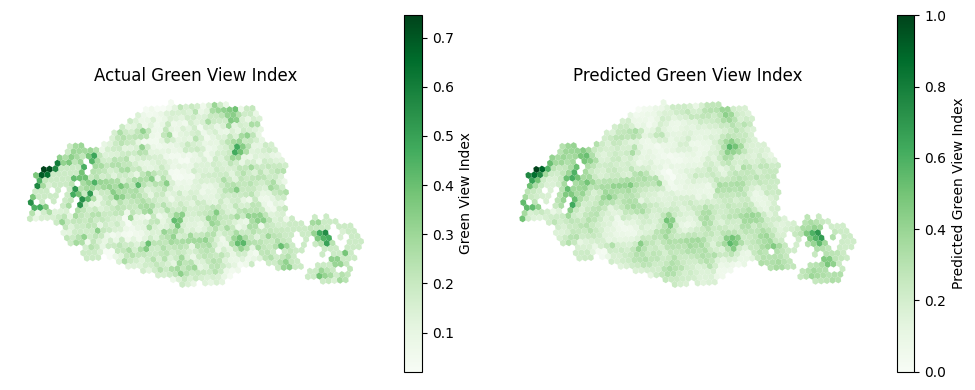

In [312]:
# load the best model
# Load best model for final evaluation
def evaluate_and_visualize_predictions(model, CompleteData, path, branch = None):
    model.load_state_dict(torch.load(path))
    if branch is not None:
        test_loss = evaluate_hybrid(CompleteData, CompleteData.test_mask, branch = branch)
    else:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask)
    print(f'Final Test Results - Loss: {test_loss:.4f}')
# Generate predictions for all nodes
    model.eval()
    with torch.no_grad():
        if branch is not None:
            predictions = model(CompleteData.x, CompleteData.pe, CompleteData.edge_index, branch = branch).squeeze().cpu().numpy()
        else:
            predictions = model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().cpu().numpy()
#normalize predictions
    scaler = MinMaxScaler()
    predictions = scaler.fit_transform(predictions.reshape(-1, 1)).flatten()
# Add predictions back to the geodataframe for visualization
    h3_nodes['predicted_green_view_performer'] = predictions
# Visualize results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Actual Green View Index
    h3_nodes.plot(column='Green View', cmap='Greens', markersize=2,
                     legend=True, ax=ax1, legend_kwds={'label': "Green View Index"})
    ax1.set_title('Actual Green View Index')
    ax1.set_axis_off()
# Predicted Green View Index
    h3_nodes.plot(column='predicted_green_view_performer', cmap='Greens', markersize=2,
                     legend=True, ax=ax2, legend_kwds={'label': "Predicted Green View Index"})
    ax2.set_title('Predicted Green View Index')
    ax2.set_axis_off()
    plt.tight_layout()
    plt.show()
    h3_nodes.drop(columns=['predicted_green_view_performer'], inplace=True)

# Usage example
evaluate_and_visualize_predictions(gat_model, CompleteData, 'best_models_paris/best_hex_model_GNN.pth')

Utility functions

In [230]:
def edge_attn_to_dense(edge_index, alpha, num_nodes, num_heads):
    """
    edge_index : [2, E]  (source, target) – same ordering as alpha
    alpha      : [E, heads]
    returns    : heads × N × N tensor
    """
    heads = []
    for h in range(num_heads):
        A = torch.zeros((num_nodes, num_nodes),
                        dtype=alpha.dtype, device=alpha.device)
        src, dst = edge_index
        A[src, dst] = alpha[:, h]  
        heads.append(A)
    return torch.stack(heads, dim=0)       # [H, N, N]

def make_capture_dict(model, data, model_type='GATv2'):
    """
    Uses get_attention_weights to obtain attention matrices for all layers and heads.
    Returns dict {(layer_idx, head_idx): N×N tensor}
    """
    attn_dict = {}
    model.eval()
    
    with torch.no_grad():
        if model_type == 'GATv2':
            if hasattr(model, 'gat_layers'):
                model.layers = model.gat_layers
        elif model_type == 'Performer':
            if hasattr(model, 'transformer_layers'):
                model.layers = model.transformer_layers

        
        for layer_idx in range(len(model.layers)):
            # Get attention weights for this layer
            if model_type == 'GATv2':
                # For GATv2, get_attention_weights returns (edge_index, attention_weights)
                att_edge_index, attention_weights = model.get_attention_weights(
                    data.x, data.pe, data.edge_index, layer_idx=layer_idx
                )
            
                # Convert edge-based attention to dense format
                dense_attention = edge_attn_to_dense(
                    att_edge_index, 
                    attention_weights, 
                    data.num_nodes, 
                    attention_weights.size(1)  # Number of heads
                )
                
                # Store each head's attention matrix separately in the dictionary
                for head_idx in range(dense_attention.size(0)):
                    attn_dict[(layer_idx, head_idx)] = dense_attention[head_idx].cpu()

            elif model_type == 'Performer':
                attention_scores = model.get_performer_attention(data.x, data.pe, data.edge_index, layer_idx=layer_idx)
                attention_scores = attention_scores.squeeze(0)  # Remove batch dimension
                for head_idx in range(attention_scores.size(0)):
                    attn_dict[(layer_idx, head_idx)] = attention_scores[head_idx].cpu()
    
    return attn_dict

def plot_top_k_attention_edges(attention_matrix, h3_nodes, top_k=50):
    """
    Plots the top-k attention edges from the attention matrix.
    
    Args:
        attention_matrix: Attention matrix of shape [heads, num_nodes, num_nodes]
        h3_nodes: GeoDataFrame containing node geometries
        top_k: Number of top attention edges to plot
    """
    
    # Find top-k attention pairs
    flattened_attn = attention_matrix.flatten()
    top_indices = np.argsort(flattened_attn)[-top_k:][::-1]
    num_nodes = attention_matrix.shape[1]
    sources = top_indices // num_nodes
    targets = top_indices % num_nodes
    
    # Create geometry and attributes
    edges = []
    for i, j, att in zip(sources, targets, flattened_attn[top_indices]):
        source_h3_id = reverse_mapping[i]
        target_h3_id = reverse_mapping[j]
        source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
        target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
        edges.append({
            'source': source_h3_id, 'target': target_h3_id, 'attention': float(att),
            'geometry': LineString([source_point, target_point])
        })
    
    # Plot the data
    gdf_edges = gpd.GeoDataFrame(edges, geometry='geometry', crs=h3_nodes.crs)
    
    node_ids = set(gdf_edges['source']).union(set(gdf_edges['target']))
    source_ids = set(gdf_edges['source'])
    target_ids = set(gdf_edges['target'])
    gdf_nodes = h3_nodes[h3_nodes.index.isin(node_ids)]
    gdf_source_nodes = h3_nodes[h3_nodes.index.isin(source_ids)]
    gdf_target_nodes = h3_nodes[h3_nodes.index.isin(target_ids)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # First subplot
    h3_nodes.plot(ax=ax1, color='lightgrey', alpha=0.3, linewidth=0.2)
    gdf_edges.plot(column='attention', cmap='viridis', linewidth=1.5, ax=ax1, 
                   legend=True, legend_kwds={'label': "Attention"})
    gdf_source_nodes.plot(ax=ax1, color='red', markersize=5, alpha=0.5)
    gdf_target_nodes.plot(ax=ax1, color='blue', markersize=5, alpha=0.5)
    # Add legend for source and target nodes
    ax1.scatter([], [], color='red', label='Source Nodes', s=5)
    ax1.scatter([], [], color='blue', label='Target Nodes', s=5)
    ax1.legend()
    ax1.set_title(f'Top {top_k} Attention Edges')
    ax1.set_axis_off()

    # Second subplot with different color scheme
    h3_nodes.plot(ax=ax2, color='lightgrey', alpha=0.3, linewidth=0.2)
    gdf_source_nodes.plot(ax=ax2, color='red', markersize=5, alpha=0.5)
    gdf_target_nodes.plot(ax=ax2, color='blue', markersize=5, alpha=0.5)
    # Add legend for source and target nodes
    ax2.scatter([], [], color='red', label='Source Nodes', s=5)
    ax2.scatter([], [], color='blue', label='Target Nodes', s=5)
    ax2.legend()
    ax2.set_title(f'Top {top_k} Attention Edges (without edges)')
    ax2.set_axis_off()

    plt.tight_layout()
    plt.show()

def analyze_head_correlations_within_layer(model, data, model_type, layer_idx=0 ,visualize=True):
    """
    Analyze correlations between different attention heads within the same layer.
    
    Args:
        model: The trained model
        data: The graph data object
        layer_idx: Index of the layer to analyze
        visualize: Whether to create visualizations
        
    Returns:
        correlation_matrix: Matrix of correlations between heads
    """
    print(f"Analyzing correlations between attention heads in Layer {layer_idx}")
    if model_type == 'GATv2':
        # For GAT, get_attention_weights returns (edge_index, attention_weights)
        att_edge_index, attention_weights = model.get_attention_weights(
            data.x, data.pe, data.edge_index, layer_idx=layer_idx
        )
        
        # Convert edge-based attention to dense format
        dense_attention = edge_attn_to_dense(
            att_edge_index, 
            attention_weights, 
            data.num_nodes, 
            attention_weights.size(1)  # Number of heads
        )
        
        # Convert to numpy for correlation calculations
        attention = dense_attention.cpu().numpy()
    elif model_type == 'Performer':
        attention_scores = model.get_performer_attention(data.x, data.pe, data.edge_index, layer_idx=layer_idx)
        attention = attention_scores.squeeze(0)  # Remove batch dimension

    num_heads = attention.shape[0]
    
    # Initialize a correlation matrix
    correlation_matrix = np.zeros((num_heads, num_heads))
    
    # Create a plot for visualizing correlations
    if visualize:
        f, ax = plt.subplots(figsize=(3, 3))
    
    # For each pair of heads, compute correlation of attention patterns
    for i in range(num_heads):
        for j in range(num_heads):
            # Flatten attention matrices for both heads
            head_i_attn = attention[i].flatten()
            head_j_attn = attention[j].flatten()
            
            # Compute correlation
            correlation = np.corrcoef(head_i_attn, head_j_attn)[0, 1]
            correlation_matrix[i, j] = correlation
    
    # Plot the correlation matrix
    if visualize:
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                   xticklabels=range(num_heads), yticklabels=range(num_heads))
        plt.title(f"Head Correlations in Layer {layer_idx}")
        plt.tight_layout()
        plt.show()
    
    return correlation_matrix


def fuse_heads(layer_mats, method="mean"):
    # layer_mats : list [A^ℓ_h0, A^ℓ_h1, ...]
    stack = torch.stack(layer_mats, 0)    # H × N × N
    if method == "mean":
        return stack.mean(0)
    if method == "rms":
        return (stack.pow(2).mean(0)).sqrt()
    if method == "max":
        return stack.max(0)[0]
    raise ValueError

def make_attention_graph(model, data, model_type ,fuse="mean", corr_thresh=0.5):
    """
    Creates an attention flow graph from model layers.
    
    Args:
        model: The trained model
        data: The graph data object
        model_type: Type of model ("GATv2" or "Performer")
        fuse: Method to fuse attention heads ("mean" or "rms" or "max" or "aware")
        
    Returns:
        Dense N×N tensor representing attention flow through the network
    """
    attn_dict = make_capture_dict(model, data, model_type)  # {(ℓ,h): A}
    
    # Find all unique layer indices in the attention dictionary
    layers = sorted(set(layer for layer, _ in attn_dict.keys()))
    
    fused = []
    for layer in layers:
        # Get all heads for this layer
        heads = sorted(head for l, head in attn_dict.keys() if l == layer)
        
        # Collect attention matrices for all heads in this layer
        mats = [attn_dict[(layer, head)] for head in heads]
        if fuse != "aware":
            # If not using aware fusion, just fuse
            # Fuse the heads for this layer
            fused.append(fuse_heads(mats, fuse))
        else:   # aware means mean if corr > 0 and max if corr < 0
            # Start with the first head
                current_fusion = mats[0]
                
                # Iteratively fuse with subsequent heads based on correlation
                for i in range(1, len(mats)):
                    # Calculate correlation between current fusion and next head
                    fusion_flat = current_fusion.flatten()
                    next_head_flat = mats[i].flatten()
                    corr = torch.corrcoef(torch.stack([fusion_flat, next_head_flat]))[0, 1]
                    
                    # Fuse based on correlation
                    if corr > corr_thresh:
                        # Positive correlation, use mean
                        current_fusion = (current_fusion + mats[i]) / 2
                    else:
                        # If correlation is not above the threshold heads are capturing different information, cannot average
                        current_fusion = torch.maximum(current_fusion, mats[i])
                
                fused.append(current_fusion)
                
    # Multiply attention matrices from last layer to first to get flow of attention through the network
    A_flow = torch.eye(data.num_nodes)
    for A_layer in reversed(fused):
        A_flow = A_layer @ A_flow
        
    return A_flow  

Attention Graph computation and visualization

torch.Size([1228, 1228])


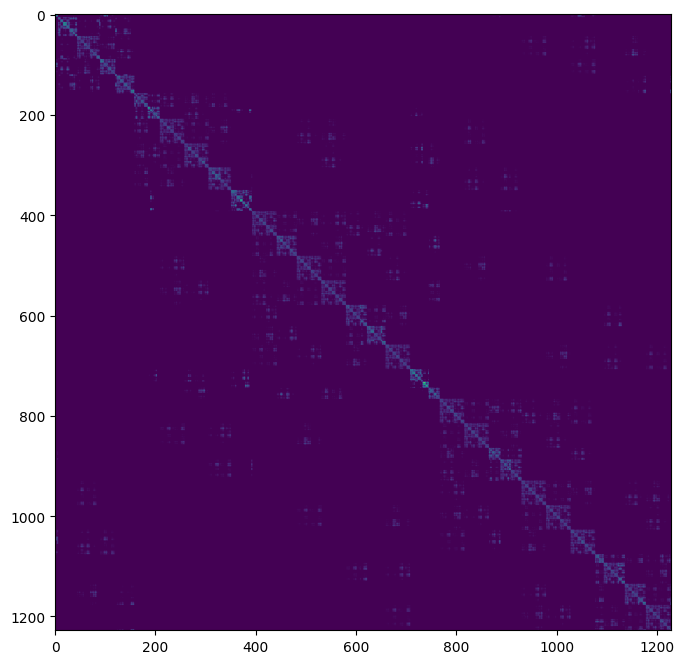

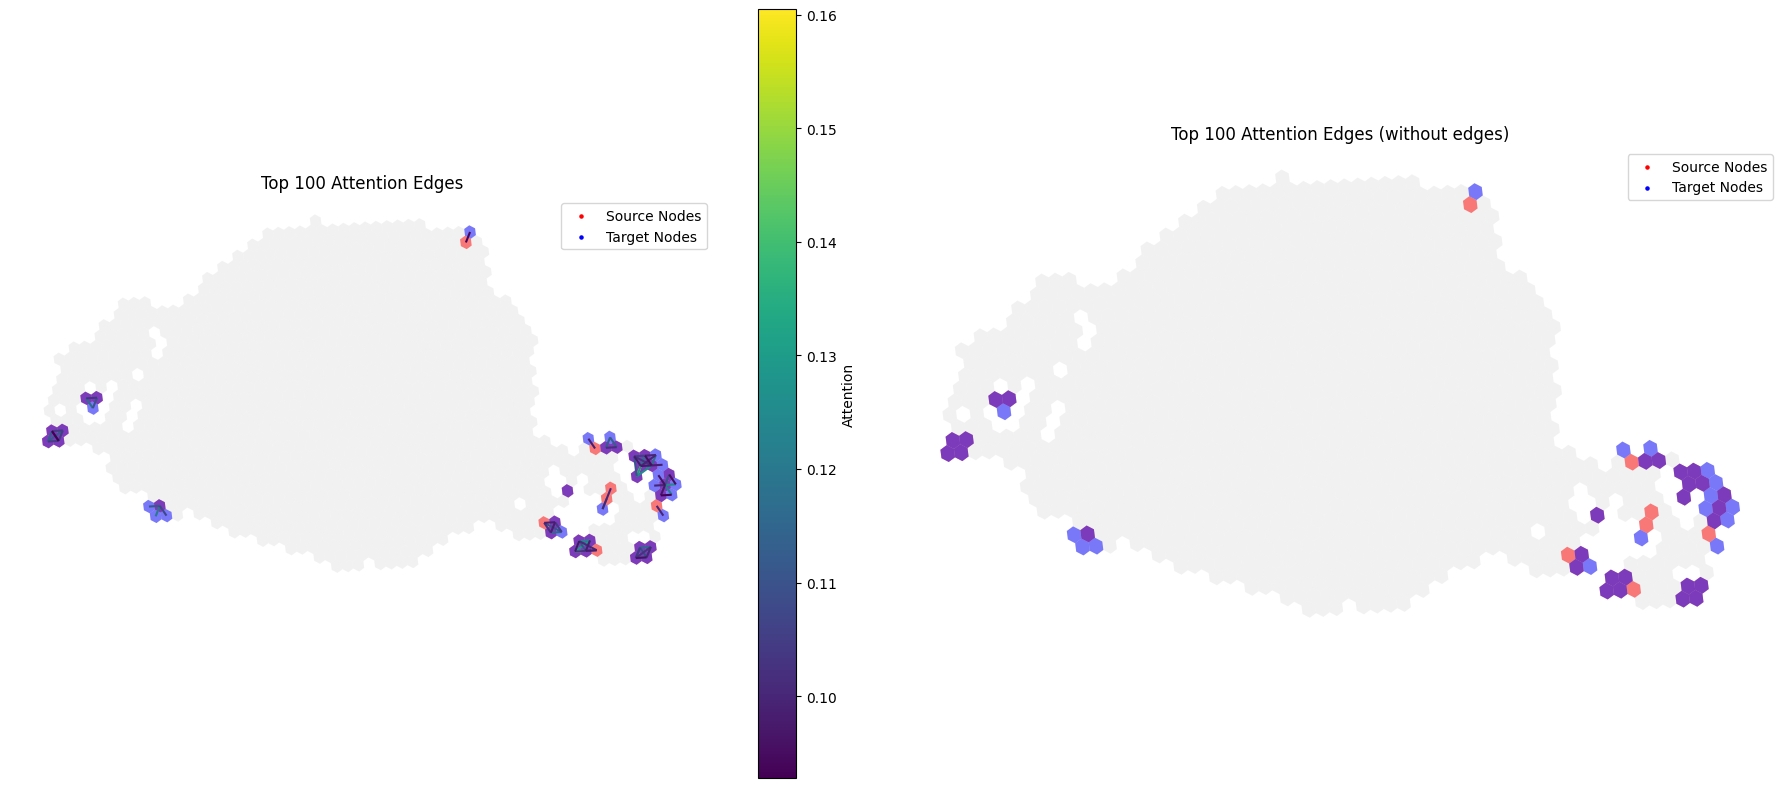

In [130]:
A_flow = make_attention_graph(gat_model, CompleteData, 'GATv2' ,fuse="mean")
print(A_flow.shape)

f, ax1 = plt.subplots(1, 1, figsize=(8, 8))
ax1.imshow(A_flow, cmap='viridis')

plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=100)


## Full Performer model

In [253]:
class PerformerModel(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        self.trans_norm = nn.LayerNorm(hidden_channels)
        # Performer layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Performer attention component only (no GAT)
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                # Normalization after attention
                
                'trans_norm': nn.LayerNorm(hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index=None, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through Performer layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Performer attention
            x_perf = x_norm.unsqueeze(0)
            x_perf = layer['attention'](x_perf).squeeze(0)
            x_perf = layer['trans_norm'](x_perf)
            
            # Residual connection (simpler now - no need to combine GAT outputs)
            x_combined = x_perf + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)
        
        # Final prediction
        return self.output_layer(x)
    
    def get_performer_attention(self, x, pe, edge_index=None, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer."""
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                x_norm = layer['norm'](x)
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_combined = x_trans + x
                x = x_combined + layer['ffn'](x_combined)
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            x = x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]
                head_k = k_prime[0, h]
                
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]

    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()

# Create the model instance
model = PerformerModel(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=4,
    dropout=0.4,
)
model.to(device)

# Test model output shape
assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == CompleteData.y.shape

In [254]:
# Training loop setup
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training function
def train_performer(data):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(pred, data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate_performer(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [255]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(CompleteData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_performer(CompleteData, CompleteData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_performer_only_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate_performer(CompleteData, CompleteData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0415, Val Loss: 0.0069, Test Loss: 0.0075
Epoch: 020, Train Loss: 0.0156, Val Loss: 0.0063, Test Loss: 0.0066
Epoch: 030, Train Loss: 0.0123, Val Loss: 0.0086, Test Loss: 0.0086
Epoch: 040, Train Loss: 0.0106, Val Loss: 0.0060, Test Loss: 0.0065
Epoch: 050, Train Loss: 0.0098, Val Loss: 0.0062, Test Loss: 0.0066
Epoch: 060, Train Loss: 0.0101, Val Loss: 0.0062, Test Loss: 0.0067
Epoch: 070, Train Loss: 0.0090, Val Loss: 0.0054, Test Loss: 0.0062
Epoch: 080, Train Loss: 0.0093, Val Loss: 0.0054, Test Loss: 0.0062
Epoch: 090, Train Loss: 0.0095, Val Loss: 0.0052, Test Loss: 0.0061
Epoch: 100, Train Loss: 0.0088, Val Loss: 0.0051, Test Loss: 0.0061
Epoch: 110, Train Loss: 0.0082, Val Loss: 0.0051, Test Loss: 0.0060
Epoch: 120, Train Loss: 0.0093, Val Loss: 0.0052, Test Loss: 0.0060
Epoch: 130, Train Loss: 0.0085, Val Loss: 0.0049, Test Loss: 0.0058
Epoch: 140, Train Loss: 0.0085, Val Loss: 0.0048, Test Loss: 0.0057
Epoch: 150, Train Lo

Final Test Results - Loss: 0.0041


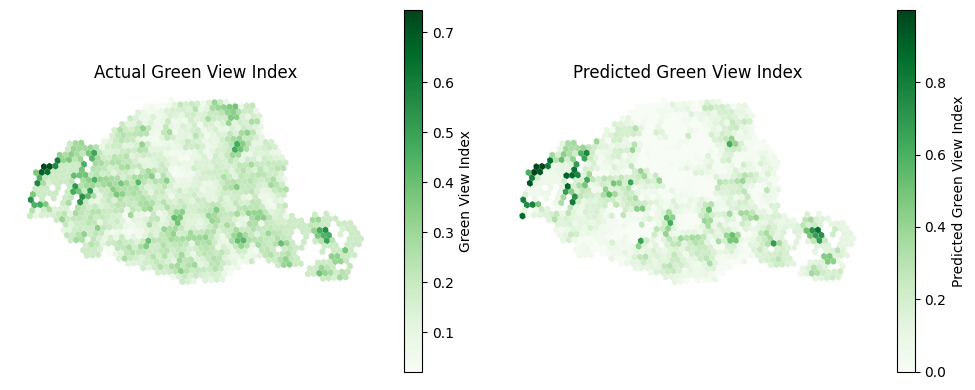

In [256]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_performer_only_model.pth')

Analyzing correlations between attention heads in Layer 0


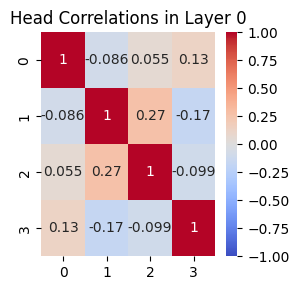

Analyzing correlations between attention heads in Layer 1


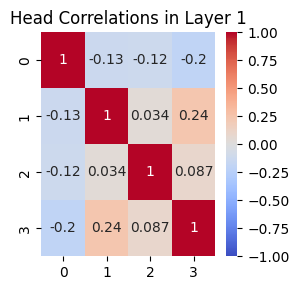

Analyzing correlations between attention heads in Layer 2


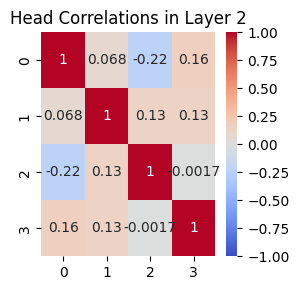

Analyzing correlations between attention heads in Layer 3


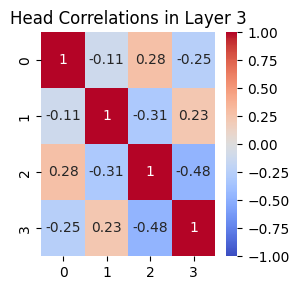

array([[ 1.        , -0.11214683,  0.27813659, -0.25378973],
       [-0.11214683,  1.        , -0.31308224,  0.22748347],
       [ 0.27813659, -0.31308224,  1.        , -0.47578681],
       [-0.25378973,  0.22748347, -0.47578681,  1.        ]])

In [257]:
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)


torch.Size([1228, 1228])


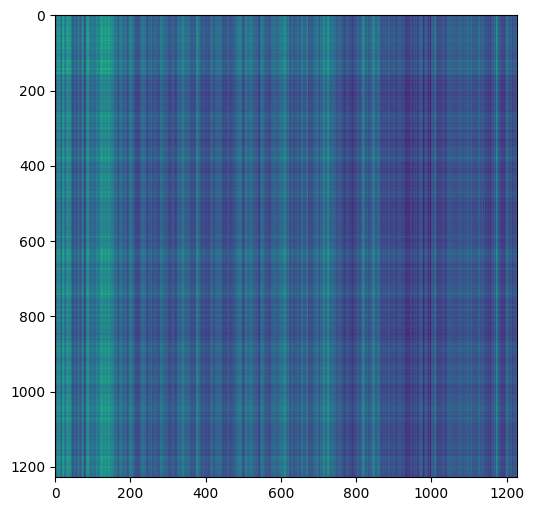

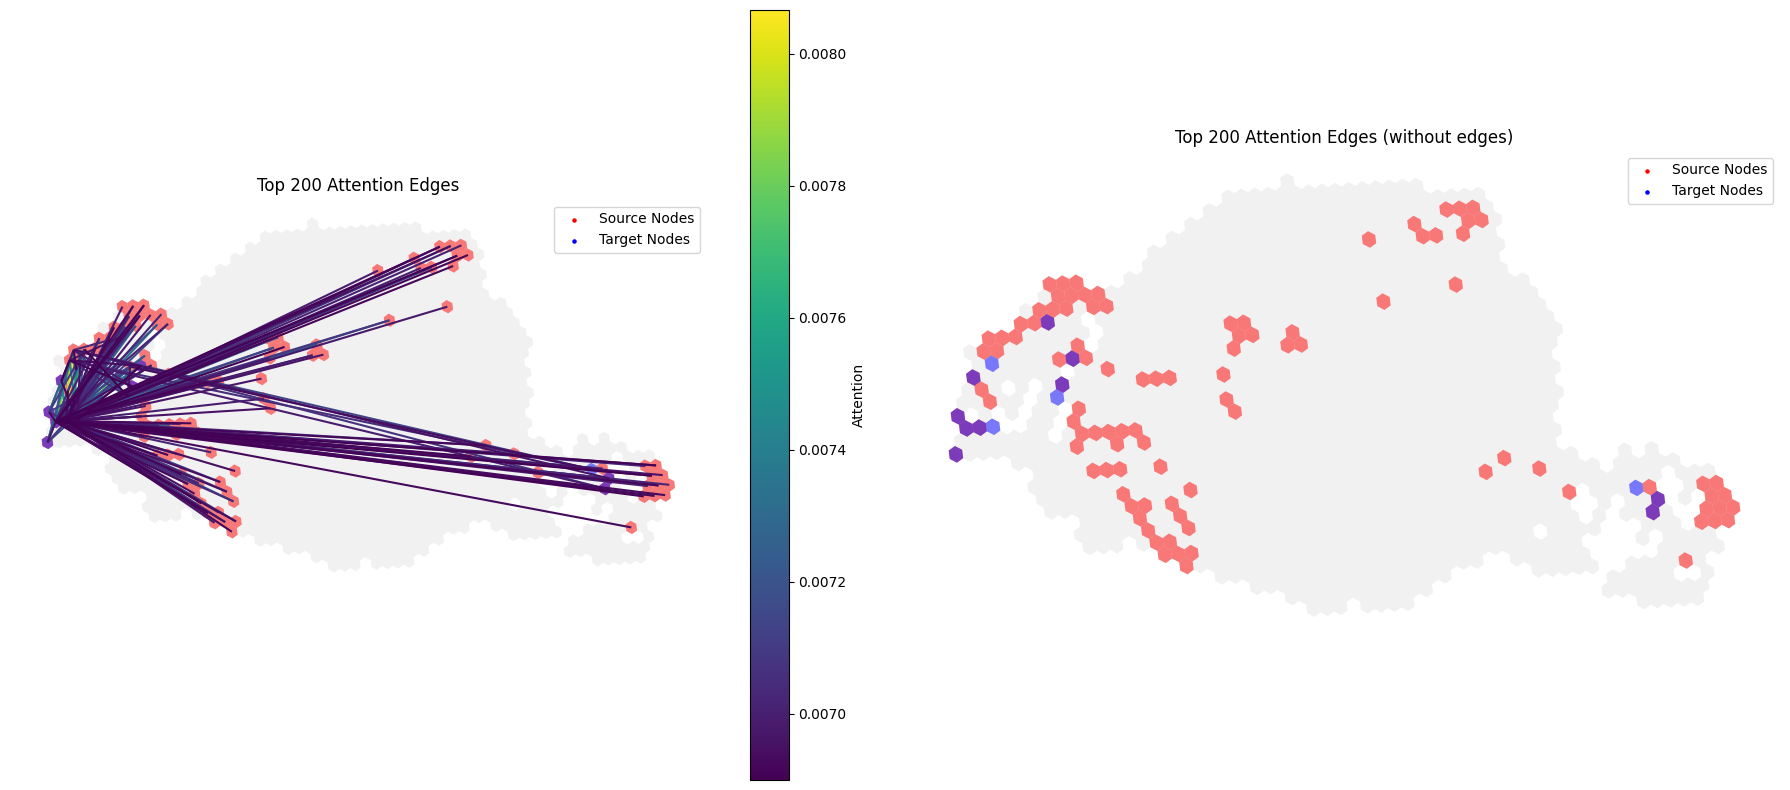

In [259]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)

f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )


plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

Basically we got results that make sense, we see that there are reference nodes once again.

# Hybrid models
## GPS - like model

In [315]:
class HybridModelv2(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
        combine_method: str = 'sum',  # 'sum', 'concat'
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)

        # GPS layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Transformer component
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                
                # GAT component
                'gat': GATv2Conv(hidden_channels, hidden_channels // heads, 
                               heads=heads, concat=True, dropout=dropout),

                # Normalization
                'trans_norm': nn.LayerNorm(hidden_channels),
                'gat_norm': nn.LayerNorm(hidden_channels),
                
                # Combination method
                'combine': self._make_combiner(combine_method, hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def _make_combiner(self, method, hidden_channels):
        if method == 'sum':
            return nn.Identity()
        elif method == 'concat':
            return nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GPS layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Transformer component
            x_trans = x_norm.unsqueeze(0)
            x_trans = layer['attention'](x_trans).squeeze(0)
            x_trans = layer['trans_norm'](x_trans)
            
            
            # GAT component
            x_gat = layer['gat'](x_norm, edge_index)
            x_gat = layer['gat_norm'](x_gat)
            
            
            # Combine the outputs with residual connection
            if isinstance(layer['combine'], nn.Identity):  # Sum
                x_combined = x_trans + x_gat + x  # Residual
            elif isinstance(layer['combine'], nn.Sequential):  # Concat
                x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)

        
        return self.output_layer(x)
    
       

    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Makes more sense to use this method for interpretability once the model is trained.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                # Pre-normalization
                x_norm = layer['norm'](x)
                
                # Transformer component
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_trans = layer['trans_norm'](x_trans)
                
                # GAT component
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                
                # Combine the outputs with residual connection
                if isinstance(layer['combine'], nn.Identity):  # Sum
                    x_combined = x_trans + x_gat + x  # Residual
                elif isinstance(layer['combine'], nn.Sequential):  # Concat
                    x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
                
                # Feed-forward network with residual
                x = x_combined + layer['ffn'](x_combined)
            
            # Now x contains the input to the target layer
            # Get the target layer
            layer = self.layers[layer_idx]
            
            # Apply layer norm
            x_norm = layer['norm'](x)
            
            # Add batch dimension for attention
            x = x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            # This is analogous to softmax(QK^T) in standard attention
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)  # Sum over nodes
            
            # For explicit attention weights (inefficient but interpretable)
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]

    def get_attention_weights(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges+nodes, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                # Pre-normalization
                x_norm = layer['norm'](x)
                
                # Transformer component
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_trans = layer['trans_norm'](x_trans)
                
                # GAT component
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                
                # Combine the outputs with residual connection
                if isinstance(layer['combine'], nn.Identity):  # Sum
                    x_combined = x_trans + x_gat + x  # Residual
                elif isinstance(layer['combine'], nn.Sequential):  # Concat
                    x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
                
                # Feed-forward network with residual
                x = x_combined + layer['ffn'](x_combined)
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            
            # Return the edge_index and attention weights
            # For GATv2Conv, we use return_attention_weights=True to get attention weights
            _, (att_edge_ind, attention_weights) = layer['gat'](x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights

    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()


model = HybridModelv2(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [319]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(CompleteData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model, CompleteData, CompleteData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hybridv2_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0114, Val Loss: 0.0054, Test Loss: 0.0062
Epoch: 020, Train Loss: 0.0094, Val Loss: 0.0051, Test Loss: 0.0060
Epoch: 030, Train Loss: 0.0082, Val Loss: 0.0049, Test Loss: 0.0059
Epoch: 040, Train Loss: 0.0072, Val Loss: 0.0047, Test Loss: 0.0056
Epoch: 050, Train Loss: 0.0059, Val Loss: 0.0039, Test Loss: 0.0048
Epoch: 060, Train Loss: 0.0055, Val Loss: 0.0035, Test Loss: 0.0046
Epoch: 070, Train Loss: 0.0043, Val Loss: 0.0032, Test Loss: 0.0043
Epoch: 080, Train Loss: 0.0043, Val Loss: 0.0033, Test Loss: 0.0044
Epoch: 090, Train Loss: 0.0049, Val Loss: 0.0035, Test Loss: 0.0044
Epoch: 100, Train Loss: 0.0042, Val Loss: 0.0032, Test Loss: 0.0042
Epoch: 110, Train Loss: 0.0034, Val Loss: 0.0033, Test Loss: 0.0044
Epoch: 120, Train Loss: 0.0041, Val Loss: 0.0028, Test Loss: 0.0040
Epoch: 130, Train Loss: 0.0038, Val Loss: 0.0028, Test Loss: 0.0043
Epoch: 140, Train Loss: 0.0033, Val Loss: 0.0028, Test Loss: 0.0042
Epoch: 150, Train Lo

### Attention Graph computation and visualization

Final Test Results - Loss: 0.0037


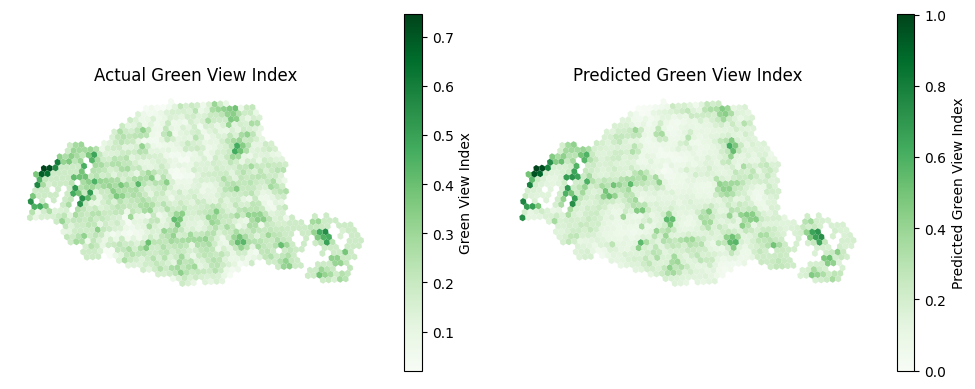

In [320]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybridv2_model.pth')

Correlation analysis for Performer part
Analyzing correlations between attention heads in Layer 0


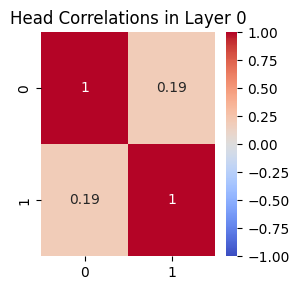

Analyzing correlations between attention heads in Layer 1


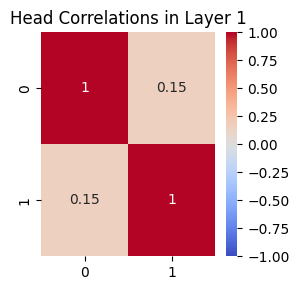

Analyzing correlations between attention heads in Layer 2


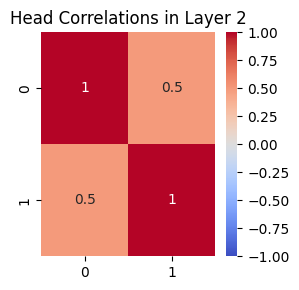

Analyzing correlations between attention heads in Layer 3


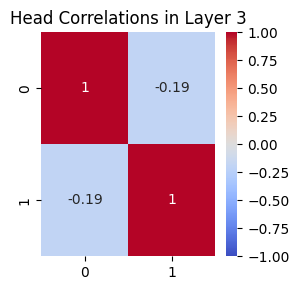

Correlation analysis for GATv2 part
Analyzing correlations between attention heads in Layer 0


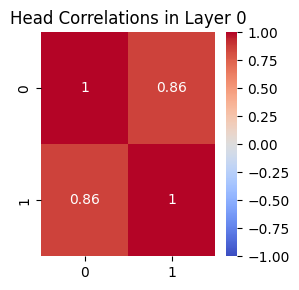

Analyzing correlations between attention heads in Layer 1


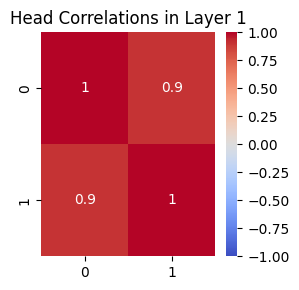

Analyzing correlations between attention heads in Layer 2


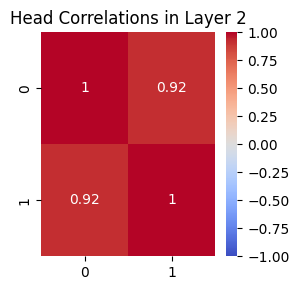

Analyzing correlations between attention heads in Layer 3


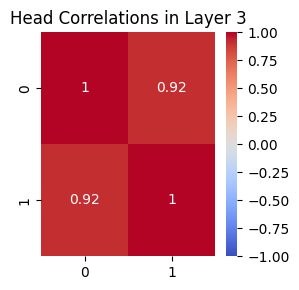

array([[1.        , 0.92164573],
       [0.92164573, 1.        ]])

In [321]:
print("Correlation analysis for Performer part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)

print("Correlation analysis for GATv2 part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='GATv2', visualize=True)


torch.Size([1228, 1228])


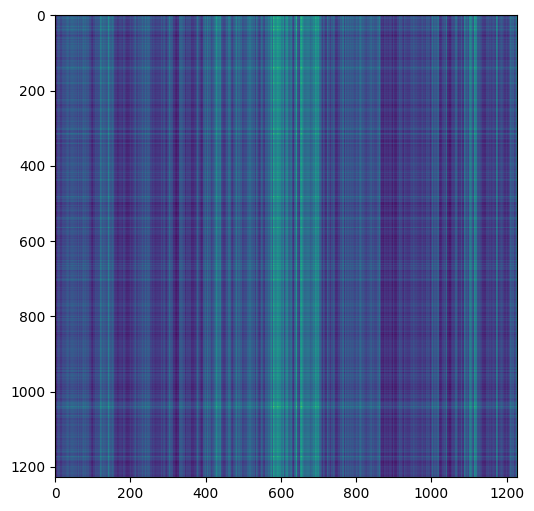

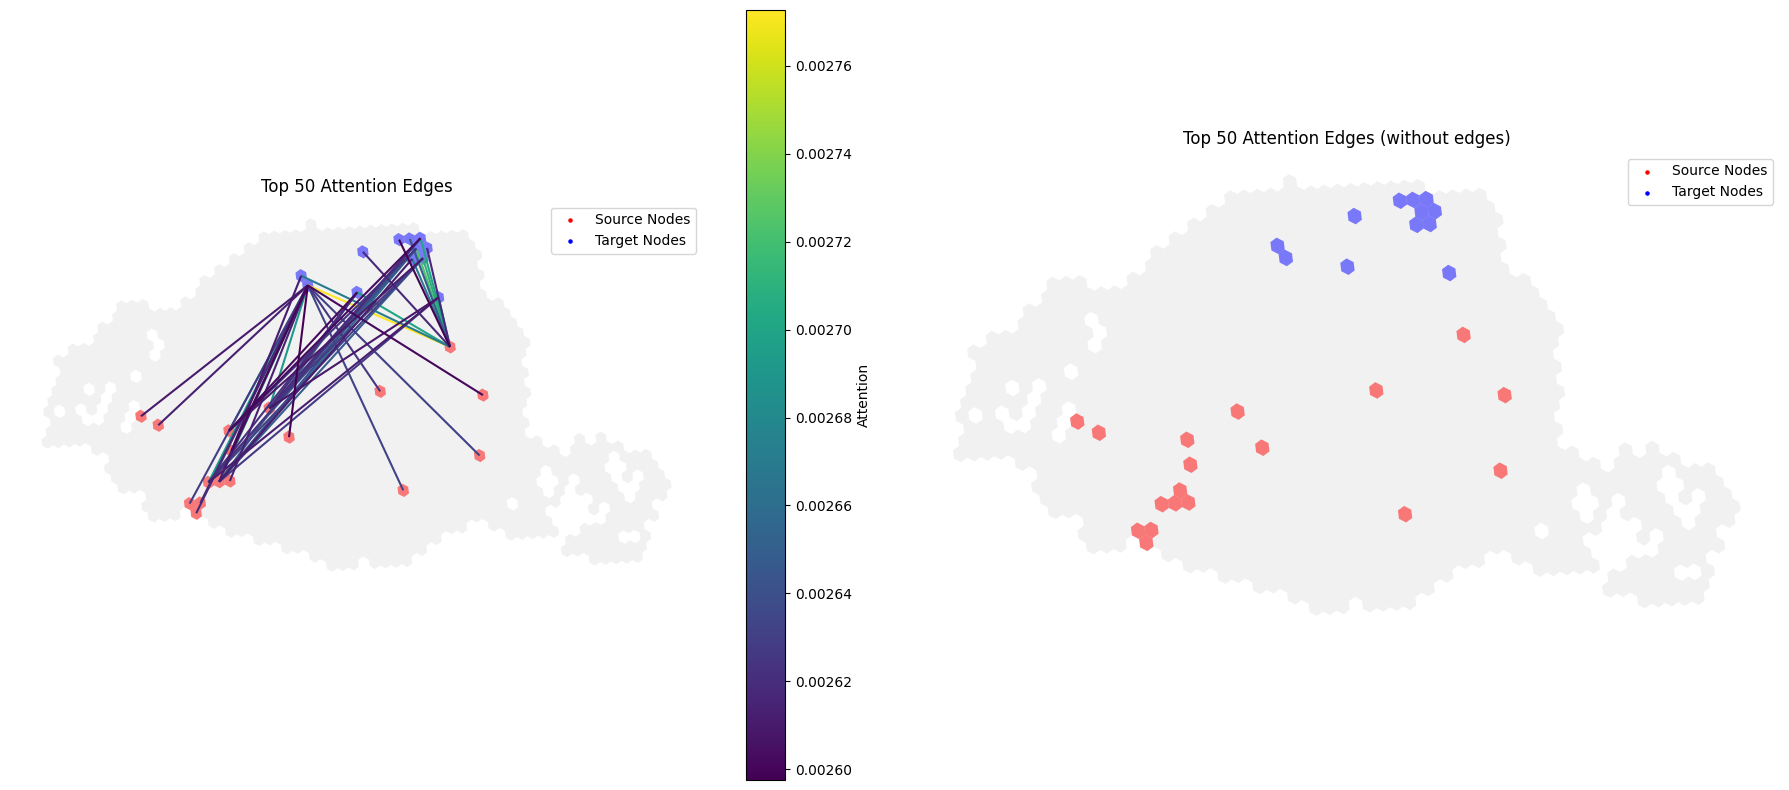

In [326]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=50)

## Independent GAT - Perf model

In [313]:
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch - improved with proper normalization and FFN
        self.gat_layers = nn.ModuleList()
        for _ in range(num_gat_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),
                
                # Post-normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.gat_layers.append(layer)
        
        # Layer normalization for transformer and GAT outputs before combining
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for node prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, branch='both'):
        """
        Forward pass with option to use specific branches.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            branch: Which branch to use ('both', 'gat', or 'performer')
        """
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        if branch in ['both', 'performer']:
            # Transformer branch
            transformer_x = x
            for layer in self.transformer_layers:
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            transformer_x = self.transformer_norm(transformer_x)
        
        if branch in ['both', 'gat']:
            # GAT branch - improved with proper residuals and FFN
            gat_x = x
            for layer in self.gat_layers:
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT (matches GAT_model design)
                gat_x = gat_x + gat_x_ff
            
            gat_x = self.gat_norm(gat_x)
        
        # Combine or use individual branch based on parameter
        if branch == 'both':
            if self.combine_method == 'sum':
                combined_x = transformer_x + gat_x
            elif self.combine_method == 'concat':
                combined_x = torch.cat([transformer_x, gat_x], dim=1)
                combined_x = F.relu(self.combine(combined_x))
        elif branch == 'performer':
            combined_x = transformer_x
        elif branch == 'gat':
            combined_x = gat_x
        
        # Final prediction
        return self.output_layer(combined_x)
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()
    
    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.transformer_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.transformer_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            transformer_x = x
            
            # Process through previous transformer layers
            for i in range(layer_idx):
                layer = self.transformer_layers[i]
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            # Get the target layer
            layer = self.transformer_layers[layer_idx]
            transformer_x_norm = layer['norm1'](transformer_x)
            
            # Add batch dimension for attention
            x = transformer_x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]
    
    def get_attention_weights(self, x, pe, edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.gat_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.gat_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            gat_x = x
            
            # Process through previous layers using the proper GAT layer structure
            for i in range(layer_idx):
                layer = self.gat_layers[i]
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT
                gat_x = gat_x + gat_x_ff
            
            # Get the target layer
            layer = self.gat_layers[layer_idx]
            gat_x_norm = layer['norm'](gat_x)
            
            # Return the edge_index and attention weights for the target layer
            # For GATv2Conv, we need to use return_attention_weights=True
            _, (att_edge_ind, attention_weights) = layer['gat'](
                gat_x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights
        

# Initialize the model
model = HybridModel_variant(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [ ]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(CompleteData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model, CompleteData, CompleteData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hybrid_variant_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0195, Val Loss: 0.0075, Test Loss: 0.0084
Epoch: 020, Train Loss: 0.0138, Val Loss: 0.0046, Test Loss: 0.0058
Epoch: 030, Train Loss: 0.0113, Val Loss: 0.0045, Test Loss: 0.0060
Epoch: 040, Train Loss: 0.0093, Val Loss: 0.0041, Test Loss: 0.0055
Epoch: 050, Train Loss: 0.0090, Val Loss: 0.0037, Test Loss: 0.0050
Epoch: 060, Train Loss: 0.0082, Val Loss: 0.0032, Test Loss: 0.0048
Epoch: 070, Train Loss: 0.0072, Val Loss: 0.0030, Test Loss: 0.0044
Epoch: 080, Train Loss: 0.0070, Val Loss: 0.0031, Test Loss: 0.0043
Epoch: 090, Train Loss: 0.0071, Val Loss: 0.0029, Test Loss: 0.0041
Epoch: 100, Train Loss: 0.0062, Val Loss: 0.0032, Test Loss: 0.0043
Epoch: 110, Train Loss: 0.0062, Val Loss: 0.0028, Test Loss: 0.0041
Epoch: 120, Train Loss: 0.0055, Val Loss: 0.0030, Test Loss: 0.0041
Epoch: 130, Train Loss: 0.0053, Val Loss: 0.0027, Test Loss: 0.0039
Epoch: 140, Train Loss: 0.0058, Val Loss: 0.0030, Test Loss: 0.0042
Epoch: 150, Train Lo

### Attention Graph computation and visualization

Final Test Results - Loss: 0.0036


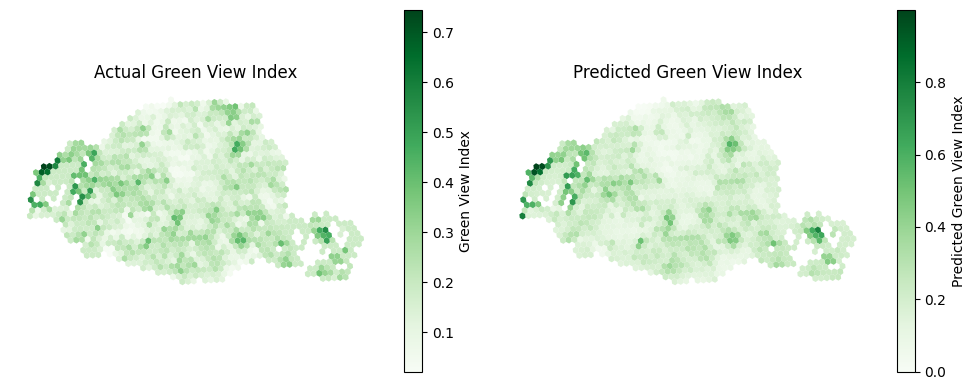

In [287]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth')

Correlation analysis for Performer part
Analyzing correlations between attention heads in Layer 0


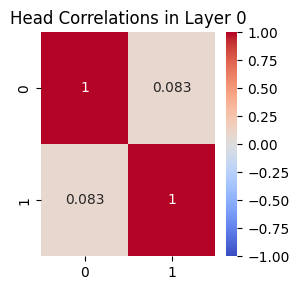

Analyzing correlations between attention heads in Layer 1


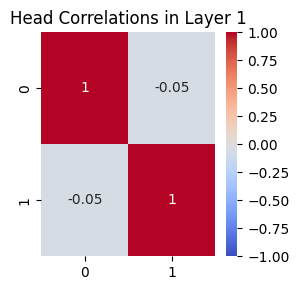

Analyzing correlations between attention heads in Layer 2


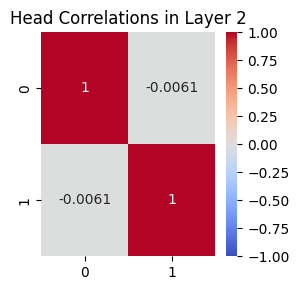

Analyzing correlations between attention heads in Layer 3


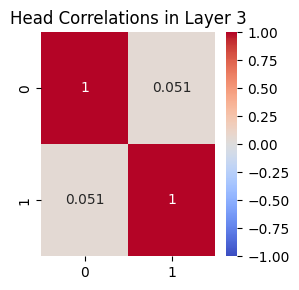

Correlation analysis for GATv2 part
Analyzing correlations between attention heads in Layer 0


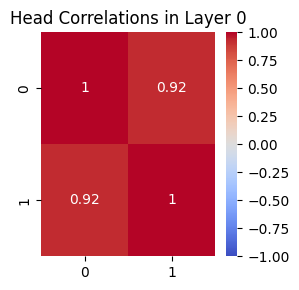

Analyzing correlations between attention heads in Layer 1


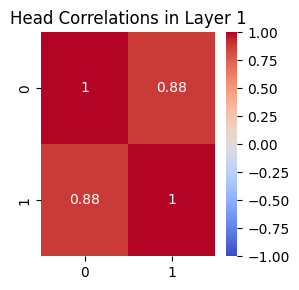

array([[1.       , 0.8821312],
       [0.8821312, 1.       ]])

In [288]:
print("Correlation analysis for Performer part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)


print("Correlation analysis for GATv2 part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='GATv2', visualize=True)

torch.Size([1228, 1228])


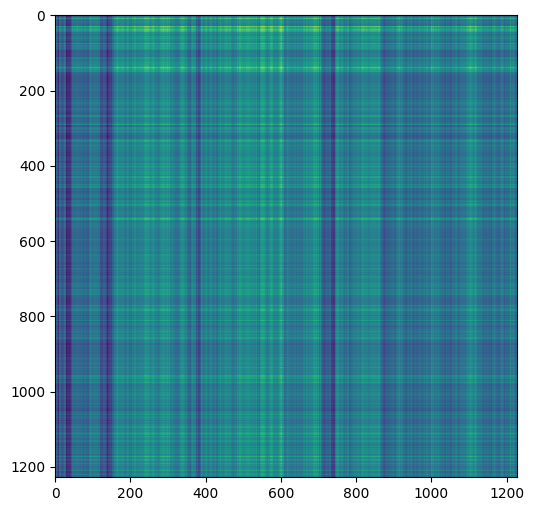

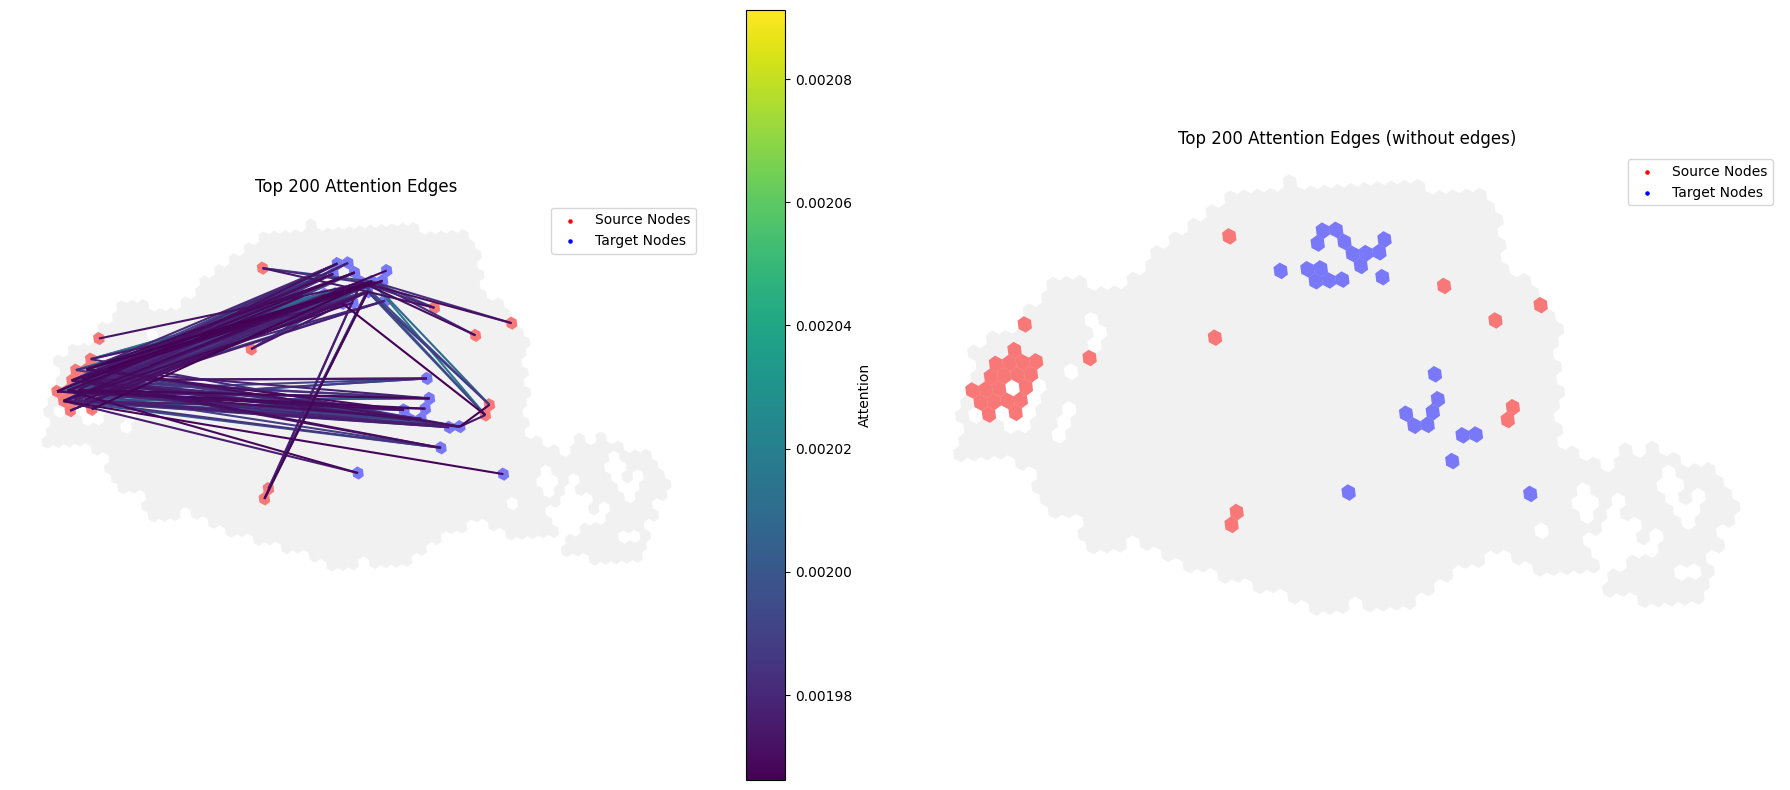

In [293]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

In [310]:
def evaluate_hybrid(data, mask, branch='both'):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index, branch=branch)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

hybrid_loss = evaluate_hybrid(CompleteData, CompleteData.test_mask, branch='both')
print(f"Hybrid model loss: {hybrid_loss:.4f}")
gat_loss = evaluate_hybrid(CompleteData, CompleteData.test_mask, branch='gat')
print(f"GAT model loss: {gat_loss:.4f}")
perf_loss = evaluate_hybrid(CompleteData, CompleteData.test_mask, branch='performer')
print(f"Performer model loss: {perf_loss:.4f}")



Hybrid model loss: 0.0036
GAT model loss: 0.0094
Performer model loss: 0.0050


Final Test Results - Loss: 0.0036


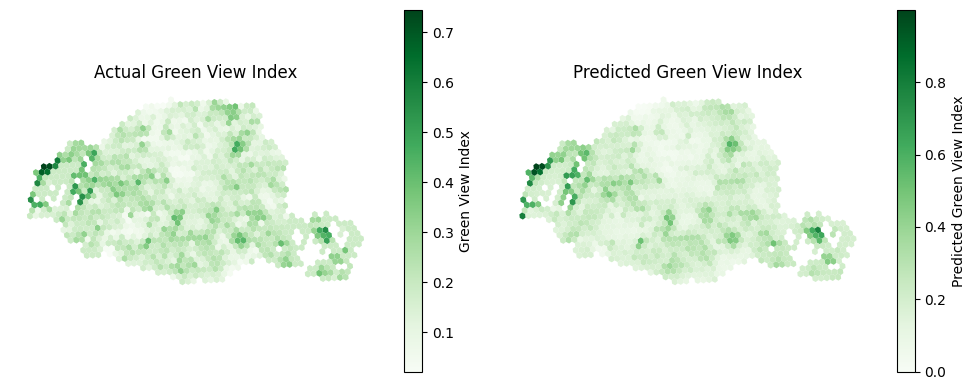

Final Test Results - Loss: 0.0094


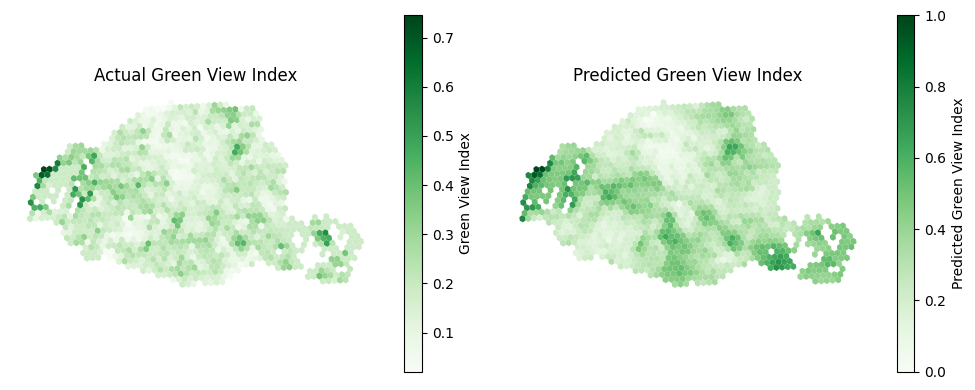

Final Test Results - Loss: 0.0050


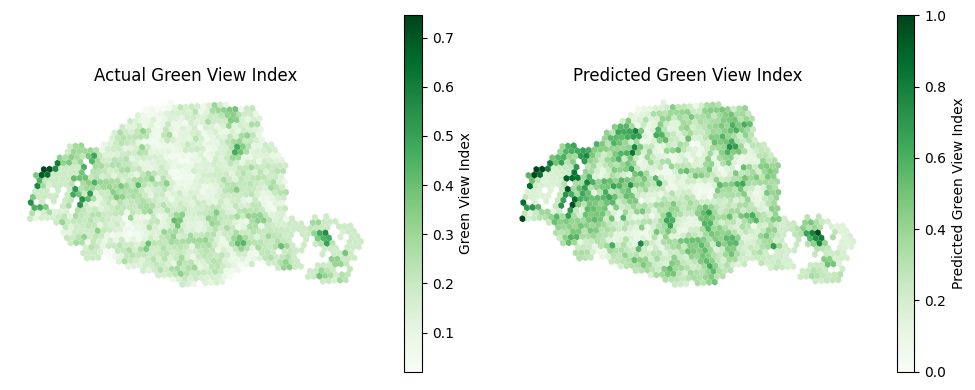

In [314]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', branch='both')
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', branch='gat')
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', branch='performer')

As we can see both GAT and Performer learn useful embeddings, but their combination actually improves the performances, so all the results are encouraging.